# 04C · Ajuste de hiperparámetros con validación temporal
## Actividad 4.2 del cronograma

Se optimiza Random Forest exclusivamente con cortes temporales dentro de 2018–2022. **2023–2024 no participa en la selección** y se usa solo para confirmación retrospectiva. El criterio principal es Average Precision media; el umbral se selecciona después con predicciones fuera de muestra de 2020–2022.

## 1. Configuración, datos y funciones

In [1]:
from pathlib import Path
import json, platform, time
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score,roc_auc_score,f1_score,precision_score,recall_score,balanced_accuracy_score,confusion_matrix,brier_score_loss

plt.style.use('seaborn-v0_8-whitegrid'); RANDOM_STATE=42
DATA_FILE=Path('../data/processed/dataset_victimas_localidad_franja_fecha.parquet')
MODELS_PATH=Path('../models/victimas'); REPORTS_PATH=Path('../reports/tuning_victimas')
MODELS_PATH.mkdir(parents=True,exist_ok=True); REPORTS_PATH.mkdir(parents=True,exist_ok=True)
dataset=pd.read_parquet(DATA_FILE); dataset['Fecha_Acc']=pd.to_datetime(dataset.Fecha_Acc)
cat_cols=['Localidad','Franja_Horaria','Dia_Semana']
num_cols=['Mes','Es_Fin_de_Semana','Es_Festivo','Accidentes_Prom_7d','Accidentes_Prom_30d','Accidentes_Semana_Anterior','Sin_Historial_Accidentes_Prom_7d','Sin_Historial_Accidentes_Prom_30d','Sin_Historial_Accidentes_Semana_Anterior']
feature_cols=cat_cols+num_cols; group_cols=['Localidad','Franja_Horaria']

def label_from_past(train,val):
    th=train.groupby(group_cols,observed=True).Num_Accidentes.quantile(2/3).rename('Umbral').reset_index()
    a=train.merge(th,on=group_cols,how='left'); b=val.merge(th,on=group_cols,how='left')
    return a,b,(a.Num_Accidentes>a.Umbral).astype(int),(b.Num_Accidentes>b.Umbral).astype(int)
def pipeline(params):
    prep=ColumnTransformer([('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols)],remainder='passthrough')
    return Pipeline([('preprocesador',prep),('modelo',RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=-1,**params))])
def calc(y,p,s):
    tn,fp,fn,tp=confusion_matrix(y,p,labels=[0,1]).ravel()
    return dict(Average_Precision=average_precision_score(y,s),AUC_ROC=roc_auc_score(y,s),F1=f1_score(y,p,zero_division=0),Precision=precision_score(y,p,zero_division=0),Recall=recall_score(y,p,zero_division=0),Balanced_Accuracy=balanced_accuracy_score(y,p),Brier=brier_score_loss(y,s),TN=tn,FP=fp,FN=fn,TP=tp)
print(dataset.shape, dataset.Fecha_Acc.min(), dataset.Fecha_Acc.max())

(204560, 16) 2018-01-01 00:00:00 2024-12-31 00:00:00


## 2. Espacio de búsqueda acotado y justificable

In [2]:
candidates=[
 {'n_estimators':200,'max_depth':12,'min_samples_leaf':20,'max_features':'sqrt','class_weight':'balanced'},
 {'n_estimators':300,'max_depth':8,'min_samples_leaf':20,'max_features':'sqrt','class_weight':'balanced'},
 {'n_estimators':300,'max_depth':16,'min_samples_leaf':20,'max_features':'sqrt','class_weight':'balanced'},
 {'n_estimators':300,'max_depth':None,'min_samples_leaf':20,'max_features':'sqrt','class_weight':'balanced'},
 {'n_estimators':300,'max_depth':12,'min_samples_leaf':10,'max_features':'sqrt','class_weight':'balanced'},
 {'n_estimators':300,'max_depth':12,'min_samples_leaf':40,'max_features':'sqrt','class_weight':'balanced'},
 {'n_estimators':300,'max_depth':12,'min_samples_leaf':20,'max_features':0.5,'class_weight':'balanced'},
 {'n_estimators':300,'max_depth':12,'min_samples_leaf':20,'max_features':'sqrt','class_weight':'balanced_subsample'},
]
param_table=pd.DataFrame(candidates); param_table.index.name='Candidato'; display(param_table)

,n_estimators,max_depth,min_samples_leaf,max_features,class_weight
Candidato,,,,,
0,200,12.0,20,sqrt,balanced
1,300,8.0,20,sqrt,balanced
2,300,16.0,20,sqrt,balanced
3,300,NaN,20,sqrt,balanced
4,300,12.0,10,sqrt,balanced
5,300,12.0,40,sqrt,balanced
6,300,12.0,20,0.5,balanced
7,300,12.0,20,sqrt,balanced_subsample


## 3. Búsqueda con cortes expansivos

In [3]:
folds=[(2019,2020),(2020,2021),(2021,2022)]; rows=[]
start=time.time()
for cid,params in enumerate(candidates):
    for train_end,val_year in folds:
        train=dataset[dataset.Fecha_Acc.dt.year<=train_end].copy(); val=dataset[dataset.Fecha_Acc.dt.year==val_year].copy()
        train,val,ytr,yv=label_from_past(train,val)
        model=pipeline(params); model.fit(train[feature_cols],ytr)
        score=model.predict_proba(val[feature_cols])[:,1]; pred=(score>=.5).astype(int)
        rows.append({'Candidato':cid,'Train_Hasta':train_end,'Validacion':val_year,**params,**calc(yv,pred,score)})
    print(f'Candidato {cid+1}/{len(candidates)} terminado')
results=pd.DataFrame(rows); results.to_csv(REPORTS_PATH/'busqueda_temporal_detalle.csv',index=False,encoding='utf-8-sig')
summary=(results.groupby('Candidato').agg(AP_Media=('Average_Precision','mean'),AP_Std=('Average_Precision','std'),AUC_Media=('AUC_ROC','mean'),F1_Medio=('F1','mean'),Recall_Medio=('Recall','mean'),Brier_Medio=('Brier','mean')).join(param_table))
summary=summary.sort_values(['AP_Media','AP_Std'],ascending=[False,True]); summary.to_csv(REPORTS_PATH/'busqueda_temporal_resumen.csv',encoding='utf-8-sig')
best_id=int(summary.index[0]); best_params=candidates[best_id]
print(f'Duración: {(time.time()-start)/60:.1f} min | Mejor candidato: {best_id}'); display(summary.round(4))

Candidato 1/8 terminado


Candidato 2/8 terminado


Candidato 3/8 terminado


Candidato 4/8 terminado


Candidato 5/8 terminado


Candidato 6/8 terminado


Candidato 7/8 terminado


Candidato 8/8 terminado
Duración: 0.7 min | Mejor candidato: 3


,AP_Media,AP_Std,AUC_Media,F1_Medio,Recall_Medio,Brier_Medio,n_estimators,max_depth,min_samples_leaf,max_features,class_weight
Candidato,,,,,,,,,,,
3,0.2552,0.0653,0.6956,0.3483,0.6784,0.2181,300,NaN,20,sqrt,balanced
2,0.2535,0.0664,0.6919,0.3394,0.7231,0.2234,300,16.0,20,sqrt,balanced
4,0.2493,0.0668,0.6854,0.3291,0.7506,0.2267,300,12.0,10,sqrt,balanced
0,0.2493,0.0658,0.6860,0.3293,0.7492,0.2269,200,12.0,20,sqrt,balanced
5,0.2487,0.0668,0.6844,0.3280,0.7450,0.2274,300,12.0,40,sqrt,balanced
7,0.2485,0.0662,0.6847,0.3298,0.7408,0.2249,300,12.0,20,sqrt,balanced_subsample
6,0.2449,0.0679,0.6808,0.3265,0.7550,0.2286,300,12.0,20,0.5,balanced
1,0.2405,0.0662,0.6719,0.3190,0.7660,0.2313,300,8.0,20,sqrt,balanced


## 4. Comparación y estabilidad del ajuste

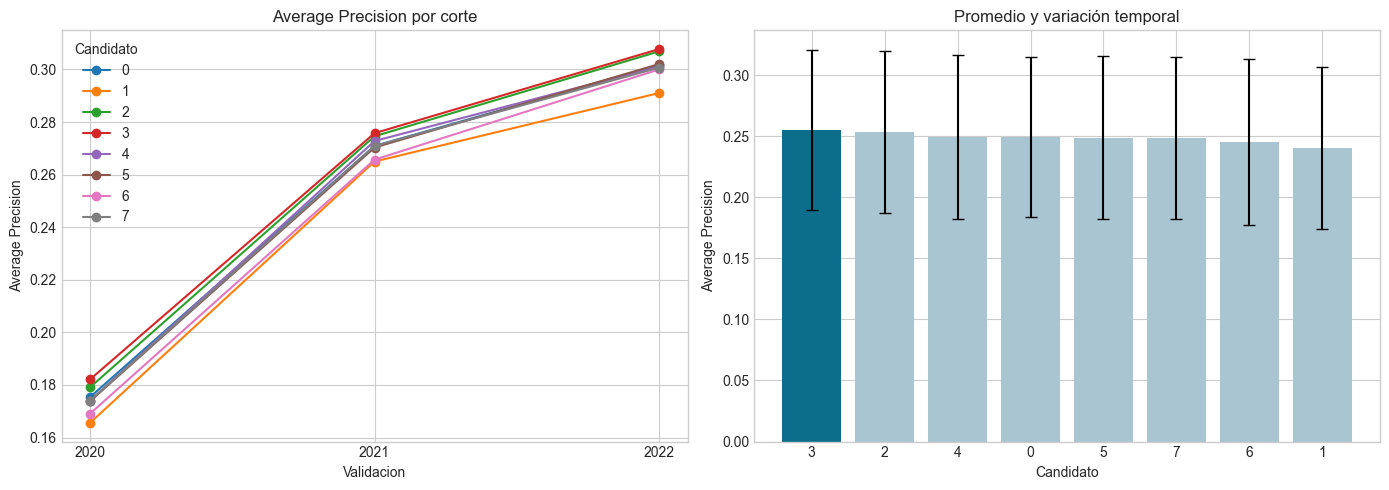

In [4]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
plot=results.pivot(index='Validacion',columns='Candidato',values='Average_Precision')
plot.plot(marker='o',ax=axes[0]); axes[0].set(title='Average Precision por corte',ylabel='Average Precision',xticks=[2020,2021,2022])
axes[1].bar(summary.index.astype(str),summary.AP_Media,yerr=summary.AP_Std,color=['#0C6E8A' if i==best_id else '#A8C5D1' for i in summary.index],capsize=4)
axes[1].set(title='Promedio y variación temporal',xlabel='Candidato',ylabel='Average Precision')
plt.tight_layout(); plt.savefig(REPORTS_PATH/'01_busqueda_hiperparametros.png',dpi=170,bbox_inches='tight'); plt.show()

## 5. Predicciones fuera de muestra y selección del umbral

Umbral temporal seleccionado: 0.5199999999999999


,Umbral,Average_Precision,AUC_ROC,F1,Precision,Recall,Balanced_Accuracy,Brier,TN,FP,FN,TP
94,0.520,0.2647,0.7002,0.3577,0.2491,0.6341,0.6483,0.2181,49376,25146,4815,8343
93,0.515,0.2647,0.7002,0.3562,0.2460,0.6453,0.6480,0.2181,48498,26024,4667,8491
95,0.525,0.2647,0.7002,0.3574,0.2510,0.6205,0.6467,0.2181,50156,24366,4994,8164
92,0.510,0.2647,0.7002,0.3563,0.2442,0.6591,0.6494,0.2181,47675,26847,4486,8672
96,0.530,0.2647,0.7002,0.3570,0.2529,0.6067,0.6451,0.2181,50943,23579,5175,7983


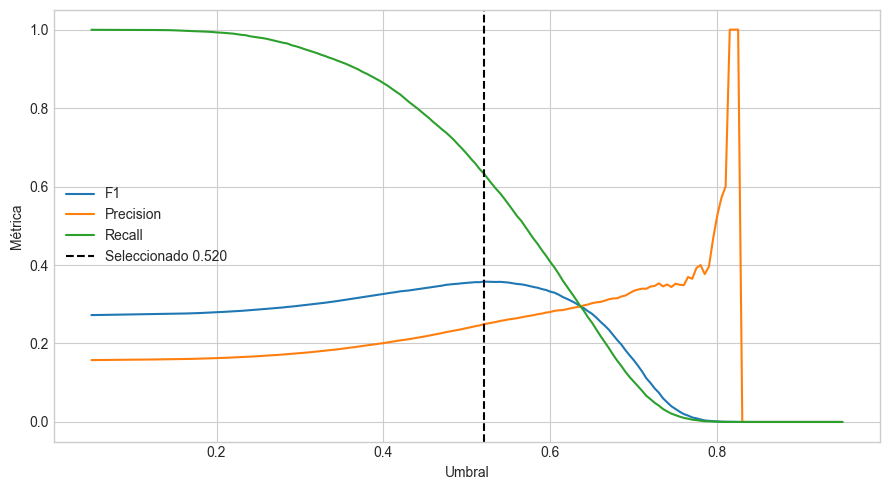

In [5]:
oof=[]
for train_end,val_year in folds:
    train=dataset[dataset.Fecha_Acc.dt.year<=train_end].copy(); val=dataset[dataset.Fecha_Acc.dt.year==val_year].copy()
    train,val,ytr,yv=label_from_past(train,val); model=pipeline(best_params); model.fit(train[feature_cols],ytr)
    score=model.predict_proba(val[feature_cols])[:,1]
    oof.append(pd.DataFrame({'Fecha_Acc':val.Fecha_Acc.to_numpy(),'Localidad':val.Localidad.to_numpy(),'Franja_Horaria':val.Franja_Horaria.to_numpy(),'Alto_Riesgo':yv.to_numpy(),'Score':score}))
oof=pd.concat(oof,ignore_index=True); threshold_rows=[]
for threshold in np.linspace(.05,.95,181): threshold_rows.append({'Umbral':threshold,**calc(oof.Alto_Riesgo,(oof.Score>=threshold).astype(int),oof.Score)})
thresholds=pd.DataFrame(threshold_rows); best_threshold=float(thresholds.loc[thresholds.F1.idxmax(),'Umbral'])
oof.to_parquet(REPORTS_PATH/'predicciones_oof_mejor_configuracion.parquet',index=False); thresholds.to_csv(REPORTS_PATH/'seleccion_umbral.csv',index=False,encoding='utf-8-sig')
print('Umbral temporal seleccionado:',best_threshold); display(thresholds.loc[(thresholds.Umbral-best_threshold).abs().nsmallest(5).index].round(4))
plt.figure(figsize=(9,5));
for metric in ['F1','Precision','Recall']: plt.plot(thresholds.Umbral,thresholds[metric],label=metric)
plt.axvline(best_threshold,color='black',ls='--',label=f'Seleccionado {best_threshold:.3f}'); plt.xlabel('Umbral'); plt.ylabel('Métrica'); plt.legend(); plt.tight_layout()
plt.savefig(REPORTS_PATH/'02_seleccion_umbral.png',dpi=170,bbox_inches='tight'); plt.show()

## 6. Entrenamiento final y confirmación retrospectiva

In [6]:
train=dataset[dataset.Periodo=='train'].copy(); test=dataset[dataset.Periodo=='test'].copy()
final_model=pipeline(best_params); final_model.fit(train[feature_cols],train.Alto_Riesgo.astype(int))
test_score=final_model.predict_proba(test[feature_cols])[:,1]; test_pred=(test_score>=best_threshold).astype(int)
test_metrics=pd.DataFrame([{'Modelo':'Random Forest ajustado','Umbral':best_threshold,**calc(test.Alto_Riesgo,test_pred,test_score)}])
test_metrics.to_csv(REPORTS_PATH/'confirmacion_retrospectiva_2023_2024.csv',index=False,encoding='utf-8-sig'); display(test_metrics.round(4))
joblib.dump(final_model,MODELS_PATH/'pipeline_random_forest_ajustado_victimas.pkl')
metadata={'seleccion_sin_test':True,'criterio':'Mayor Average Precision media 2020–2022','mejor_candidato':best_id,'hiperparametros':best_params,'umbral_temporal':best_threshold,'metricas_test_retro':test_metrics.iloc[0].to_dict(),'version_python':platform.python_version(),'version_sklearn':sklearn.__version__}
(MODELS_PATH/'metadata_random_forest_ajustado.json').write_text(json.dumps(metadata,indent=2,ensure_ascii=False,default=str),encoding='utf-8')
print('Modelo ajustado guardado sin reemplazar el pipeline anterior.')

,Modelo,Umbral,Average_Precision,AUC_ROC,F1,Precision,Recall,Balanced_Accuracy,Brier,TN,FP,FN,TP
0,Random Forest ajustado,0.52,0.3098,0.6933,0.4058,0.2941,0.6544,0.6428,0.2221,29895,17467,3842,7276


Modelo ajustado guardado sin reemplazar el pipeline anterior.


## Conclusión

La configuración se eligió exclusivamente con validación temporal 2020–2022. El resultado 2023–2024 es una confirmación retrospectiva y no interviene en la selección. Debe compararse el incremento de Average Precision frente al candidato base con su variación entre años: una diferencia mínima no justifica afirmar superioridad concluyente.